# Mesh operations with meshio++

Beyond reading and writing, meshio++ ships a set of dependency-free **mesh
operations** that run through the same C++ core (with a pure-Python fallback)
under every mesh backend. This notebook demonstrates the recent additions on the
bundled `example.msh` part, **rendering each result with PyVista** so the effect
is visible:

- **surface / skin extraction** — the boundary of a volume mesh,
- **quality metrics** — per-cell scaled Jacobian, aspect ratio, ...,
- **reordering** — RCM / space-filling-curve renumbering to cut bandwidth,
- **comparison (diff)** — is one mesh equal to another within a tolerance?,
- **format sniffing** — detect a file's format from its contents.

Each is also a CLI verb (`meshioplusplus surface|quality|reorder|diff ...`).

In [1]:
import os
import tempfile
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

import meshioplusplus as mp

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')


def to_pyvista(mesh):
    """meshio++ Mesh -> pyvista grid via a temporary .vtu."""
    with tempfile.NamedTemporaryFile(suffix='.vtu', delete=False) as f:
        tmp = f.name
    try:
        mp.write(tmp, mesh)
        return pv.read(tmp)
    finally:
        os.unlink(tmp)


def show(img, title=None, figsize=(9, 6)):
    """Embed a rendered RGB screenshot as a static image."""
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


def render(mesh, title, scalars=None, cmap='viridis', clim=None, color='#2ec4b6'):
    """Render a meshio++ mesh, optionally coloured by a data array."""
    grid = to_pyvista(mesh)
    try:
        pl = pv.Plotter(off_screen=True, window_size=(1000, 720))
        if scalars is not None:
            pl.add_mesh(grid, scalars=scalars, cmap=cmap, clim=clim,
                        show_edges=False, scalar_bar_args={'title': scalars})
        else:
            pl.add_mesh(grid, color=color, show_edges=True,
                        edge_color='#1f4e79', line_width=0.2)
        pl.camera_position = 'iso'
        pl.add_axes()
        img = pl.screenshot(return_img=True)
        pl.close()
        show(img, title)
    except Exception as exc:  # pragma: no cover - head-less GL fallback
        print('PyVista render skipped:', exc)

## Read the mesh

In [2]:
EXAMPLE = os.path.join(os.path.dirname(os.getcwd()), 'example', 'example.msh')
if not os.path.exists(EXAMPLE):
    EXAMPLE = 'example.msh'  # when run from the example/ folder

mesh = mp.read(EXAMPLE)
totals = Counter()
for cb in mesh.cells:
    totals[cb.type] += len(cb.data)
print('backend      :', mp._core.__mesh_backend__)
print('points       :', len(mesh.points))
print('cells by type:', dict(totals))

backend      : meshio
points       : 52282
cells by type: {'vertex': 234, 'line': 4169, 'triangle': 58394, 'tetra': 235014}


## Surface / skin extraction

`extract_surface` returns the boundary of the highest-dimension cells (volume →
boundary faces); `extract_skin` is the volume-only variant. We render the
extracted boundary surface.

surface: [('triangle', 58394)]
skin   : [('triangle', 58394)]


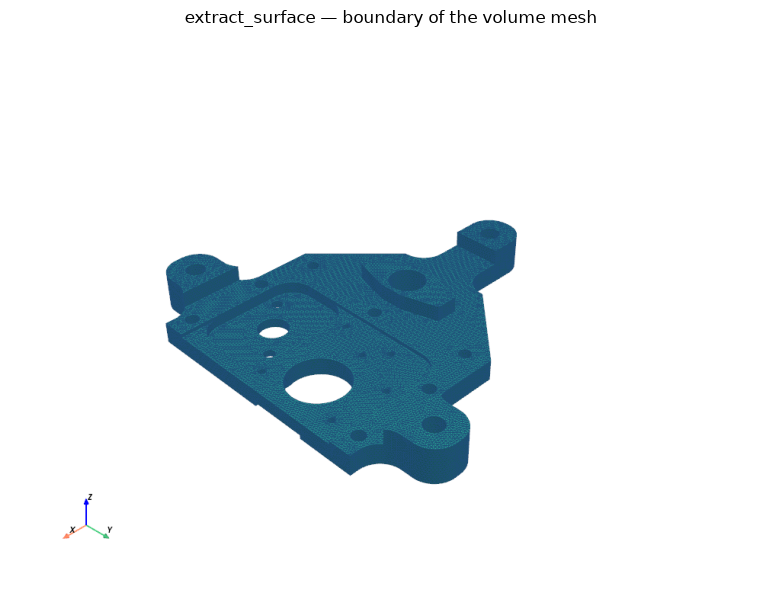

In [3]:
surface = mp.extract_surface(mesh)
skin = mp.extract_skin(mesh, linearize=True)
print('surface:', [(cb.type, len(cb.data)) for cb in surface.cells])
print('skin   :', [(cb.type, len(cb.data)) for cb in skin.cells])
render(surface, 'extract_surface — boundary of the volume mesh')

## Quality metrics

`compute_quality` scores every cell on a set of geometric metrics (and flags
inverted / degenerate cells); `attach_quality` writes them back as `cell_data`.
Below: the distribution of the scaled Jacobian over the whole part, then the
**boundary coloured by its per-triangle scaled Jacobian** (1 = ideal).

cells scored : 297811
inverted     : 0
quality:scaled_jacobian  min=0.011 mean=0.463 max=1.000
quality:aspect_ratio     min=1.000 mean=1.538 max=1439.572


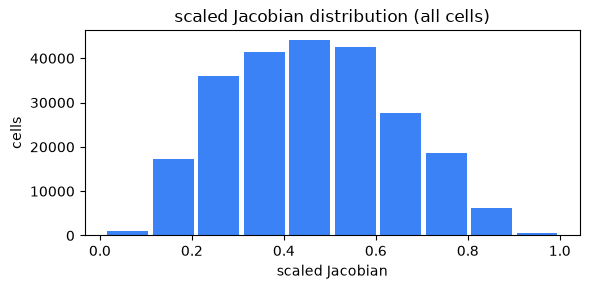

In [4]:
report = mp.compute_quality(mesh)
print('cells scored :', report['num_cells'])
print('inverted     :', report['num_inverted'])
for name in ('quality:scaled_jacobian', 'quality:aspect_ratio'):
    s = report['metrics'][name]
    print(f"{name:24s} min={s['min']:.3f} mean={s['mean']:.3f} max={s['max']:.3f}")

sj = report['metrics']['quality:scaled_jacobian']
fig, ax = plt.subplots(figsize=(6, 3))
edges = np.linspace(sj['min'], sj['max'], len(sj['histogram']) + 1)
ax.bar(0.5 * (edges[:-1] + edges[1:]), sj['histogram'],
       width=(edges[1] - edges[0]) * 0.9, color='#3b82f6')
ax.set(title='scaled Jacobian distribution (all cells)',
       xlabel='scaled Jacobian', ylabel='cells')
plt.tight_layout()
plt.show()

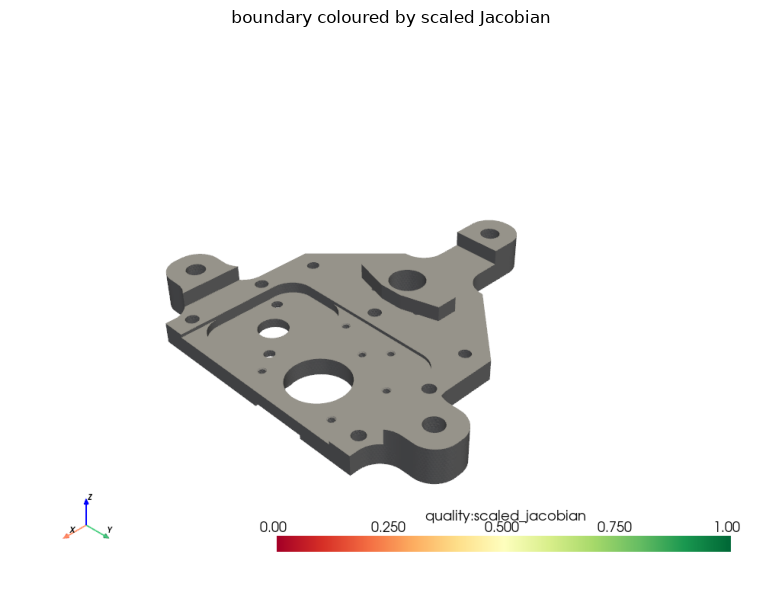

In [5]:
# colour the boundary triangles by their own scaled Jacobian
surf_q = mp.attach_quality(surface)
render(surf_q, 'boundary coloured by scaled Jacobian',
       scalars='quality:scaled_jacobian', cmap='RdYlGn', clim=(0.0, 1.0))

## Reordering / renumbering

`reorder` renumbers nodes and elements (Reverse Cuthill–McKee by default, or the
Morton / Hilbert space-filling curves) as a *pure permutation*.
`compute_bandwidth` measures the connectivity bandwidth before and after — RCM
collapses it dramatically.

*(This gmsh part carries a `gmsh:bounding_entities` cell_set of geometry ids;
we clear the side-channel sets so the demo focuses on the geometry.)*

In [6]:
plain = mp.read(EXAMPLE)
plain.cell_sets = {}
plain.point_sets = {}

before = mp.compute_bandwidth(plain)
for method in ('rcm', 'morton', 'hilbert'):
    out = mp.reorder(plain, method=method)
    print(f'{method:8s}: bandwidth {before} -> {mp.compute_bandwidth(out)}')

rcm     : bandwidth 50857 -> 1229
morton  : bandwidth 50857 -> 41980
hilbert : bandwidth 50857 -> 46623


The bandwidth is the largest node-index gap within any cell. Plotting every
connectivity **edge as a point `(i, j)`** shows it geometrically: RCM pulls all
the edges tight against the diagonal (small bandwidth), the original numbering
scatters them across the whole matrix.

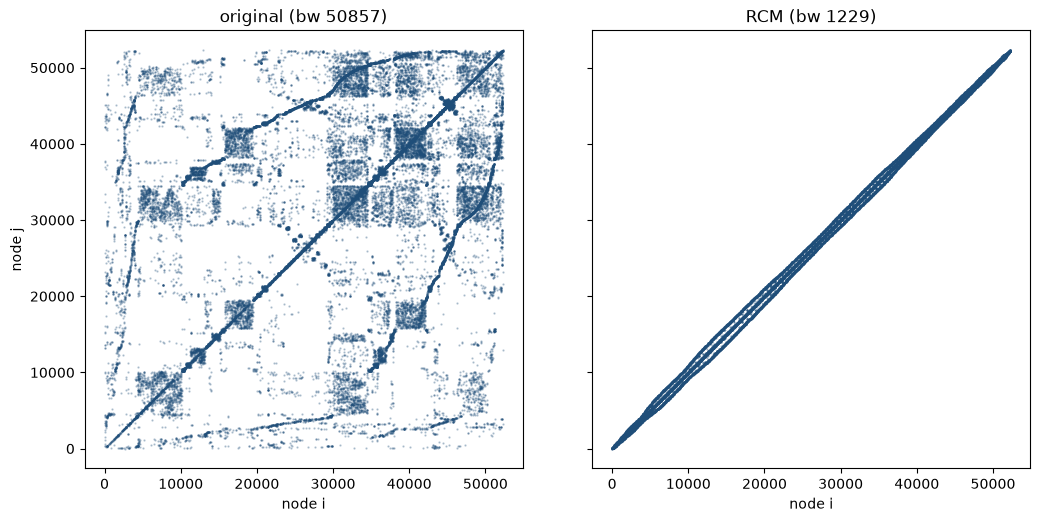

In [7]:
_, node_perm, _ = mp.reorder(plain, method='rcm', return_permutation=True)
tet = np.asarray([cb.data for cb in plain.cells if cb.type == 'tetra'][0])
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
edges = np.vstack([tet[:, [a, b]] for a, b in pairs])
rng = np.random.default_rng(0)
edges = edges[rng.choice(len(edges), size=min(40000, len(edges)), replace=False)]
after = node_perm[edges]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharex=True, sharey=True)
for ax, e, ttl in ((axes[0], edges, f'original (bw {before})'),
                   (axes[1], after, f'RCM (bw {mp.compute_bandwidth(mp.reorder(plain)) })')):
    ax.scatter(e[:, 0], e[:, 1], s=0.4, alpha=0.3, color='#1f4e79')
    ax.set(title=ttl, xlabel='node i', aspect='equal')
axes[0].set_ylabel('node j')
plt.tight_layout()
plt.show()

## Comparison (diff)

`meshes_equal` is the boolean helper for regression tests; `diff` returns a
structured report with an overall verdict. First the canonical CI pattern —
**write to another format, read it back, assert equal within tolerance**:

In [8]:
tmp = os.path.join(tempfile.mkdtemp(), 'surface.vtu')
mp.write(tmp, surface)
roundtrip = mp.read(tmp)
print('round-trip equal :', mp.meshes_equal(surface, roundtrip, atol=1e-10))

round-trip equal : True


Now a **localised deformation**: we push a bump into the surface and let `diff`
find it. The report pinpoints the worst-offending point; rendering the per-point
error shows exactly *where* the two meshes disagree.

verdict          : different
points exceeding : 25843
worst point index: 36371 | max abs error: 4.960e-02


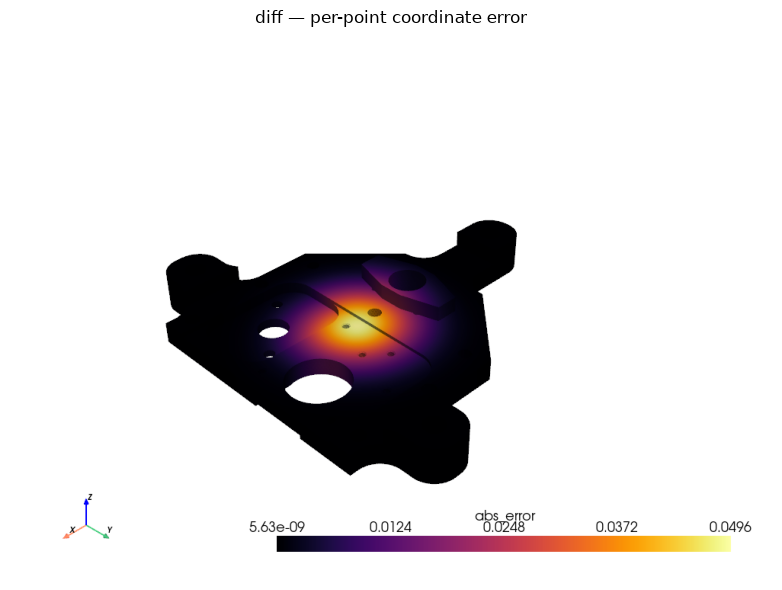

In [9]:
base = np.asarray(surface.points, dtype=float)
centre = base.mean(axis=0)
d = np.linalg.norm(base - centre, axis=1)
bump = 0.05 * np.exp(-((d / (0.25 * d.max())) ** 2))
moved = base.copy()
moved[:, 2] += bump
deformed = mp.Mesh(moved, surface.cells)

rep = mp.diff(surface, deformed, atol=1e-6, rtol=0.0)
print('verdict          :', rep['verdict'])
print('points exceeding :', rep['points']['num_exceeding'])
print('worst point index:', rep['points']['worst_index'],
      '| max abs error:', f"{rep['points']['max_abs_error']:.3e}")

err = np.linalg.norm(moved - base, axis=1)
vis = mp.Mesh(base, surface.cells, point_data={'abs_error': err})
render(vis, 'diff — per-point coordinate error', scalars='abs_error', cmap='inferno')

`diff` also has an **unordered** mode that matches nodes by spatial proximity,
so a mesh whose nodes were merely *renumbered* still compares equal. Here we take
the surface geometry and shuffle its node numbering (permute the points and remap
the connectivity, keeping the cells in place):

In [10]:
geo = mp.Mesh(base, surface.cells)             # geometry only, no data
conn = np.asarray(geo.cells[0].data)
perm = np.random.default_rng(0).permutation(len(base))   # old -> new node id
inv = np.empty(len(base), dtype=np.int64)
inv[perm] = np.arange(len(base))
shuffled = mp.Mesh(base[inv], [('triangle', perm[conn])])

print('ordered   verdict:', mp.diff(geo, shuffled)['verdict'])
print('unordered verdict:', mp.diff(geo, shuffled, unordered=True)['verdict'])

ordered   verdict: different
unordered verdict: identical


## Format sniffing

`sniff_format` detects a file's format from its leading bytes (used as a
read-side fallback when the extension is unknown).

In [11]:
print('sniffed format of the .vtu we wrote:', mp.sniff_format(tmp))

sniffed format of the .vtu we wrote: vtu


Every operation shown here is also exposed through the C API, the Fortran
module, and the WebAssembly build, and as a `meshioplusplus` CLI verb.